In [1]:
import pandas as pd

In [2]:
# Data Processing
import pandas as pd
import numpy as np
# Visualization
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
##  Model 
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor

##### scaling
from sklearn.preprocessing import StandardScaler
# Data Split
from sklearn.model_selection import train_test_split
# Parameter Tuning
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
# Model Evaluation
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
# Variance : To check assumption
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
# Model save
import pickle
# josn
import json
# warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
pip install pandas

In [4]:
Steps involed in Data Science Project
1. Problem statement
2. Data Gathering
3. EDA (Exploratory data Analysis)
   detection : missing value, outliers,noisy data? etc
4. Feature Engineering : missing value imputation, outlier handling etc
5. Feature selection : best feature selection
6. Model Selection & Model Training
   spliting data
   model training
7. Model Evaluation
   MSE,SSE,MAPE,R2,adjusted R2  :regression
8. Deployment
   api writing : flask
   api testing : postman
   html :
   github:
   azure/ gcp / aws : 

SyntaxError: invalid syntax (2739101580.py, line 1)

### 1. Problem Statement

#### 2. Data Gathering

In [6]:
# : through client : databases (mysql,no sql), VDI, email (rare case)
df = pd.read_csv("medical_insurance.csv")
df.head()

,age,gender,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


#### 3) EDA (Exploratory data Analysis)
   detection : missing value, outliers,noisy data? et

In [7]:
# detect missing values
df.isna().sum()

age         0
gender      0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [8]:
df.isna().mean()*100

age         0.0
gender      0.0
bmi         0.0
children    0.0
smoker      0.0
region      0.0
charges     0.0
dtype: float64

In [9]:
# to check noisy data
df.columns

Index(['age', 'gender', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [10]:
for col_nam in df.columns:
    print(f"{col_nam}\n",df[col_nam].unique())
    print("**********************")

age
 [19 18 28 33 32 31 46 37 60 25 62 23 56 27 52 30 34 59 63 55 22 26 35 24
 41 38 36 21 48 40 58 53 43 64 20 61 44 57 29 45 54 49 47 51 42 50 39]
**********************
gender
 ['female' 'male']
**********************
bmi
 [27.9   33.77  33.    22.705 28.88  25.74  33.44  27.74  29.83  25.84
 26.22  26.29  34.4   39.82  42.13  24.6   30.78  23.845 40.3   35.3
 36.005 32.4   34.1   31.92  28.025 27.72  23.085 32.775 17.385 36.3
 35.6   26.315 28.6   28.31  36.4   20.425 32.965 20.8   36.67  39.9
 26.6   36.63  21.78  30.8   37.05  37.3   38.665 34.77  24.53  35.2
 35.625 33.63  28.    34.43  28.69  36.955 31.825 31.68  22.88  37.335
 27.36  33.66  24.7   25.935 22.42  28.9   39.1   36.19  23.98  24.75
 28.5   28.1   32.01  27.4   34.01  29.59  35.53  39.805 26.885 38.285
 37.62  41.23  34.8   22.895 31.16  27.2   26.98  39.49  24.795 31.3
 38.28  19.95  19.3   31.6   25.46  30.115 29.92  27.5   28.4   30.875
 27.94  35.09  29.7   35.72  32.205 28.595 49.06  27.17  23.37  37.1
 23.75 

In [11]:
# statstic values
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   gender    1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [13]:
df[["age","bmi","children","charges"]].head()

,age,bmi,children,charges
0,19,27.900,0,16884.92400
1,18,33.770,1,1725.55230
2,28,33.000,3,4449.46200
3,33,22.705,0,21984.47061
4,32,28.880,0,3866.85520


In [14]:
df.select_dtypes(include="number").head()

,age,bmi,children,charges
0,19,27.900,0,16884.92400
1,18,33.770,1,1725.55230
2,28,33.000,3,4449.46200
3,33,22.705,0,21984.47061
4,32,28.880,0,3866.85520


In [15]:
df.select_dtypes(exclude="number").head()

,gender,smoker,region
0,female,yes,southwest
1,male,no,southeast
2,male,no,southeast
3,male,no,northwest
4,male,no,northwest


In [16]:
df_num = df.select_dtypes(include="number")
df_num.corr()

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


<Axes: >

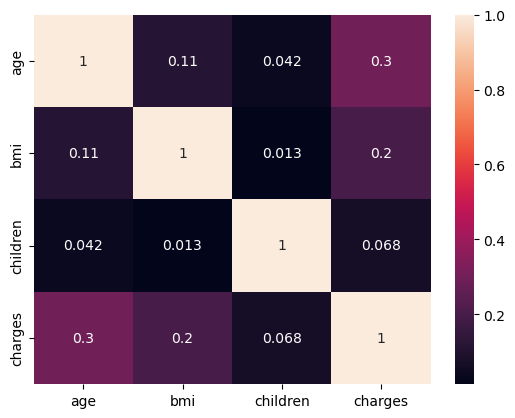

In [17]:
sns.heatmap(df_num.corr(),annot=True)

In [18]:
# vif : between independent variables
# print(df.columns)  # remove target column
df1 = df.drop(["charges","sex","smoker",	"region"],axis=1)
df1.head(1)

KeyError: "['sex'] not found in axis"

In [ ]:
x_with_constant = sm.add_constant(df1)

In [ ]:
vif_list = [variance_inflation_factor(x_with_constant.values,i) for i in range(x_with_constant.shape[1])]
vif_list

In [ ]:
s1 = pd.Series(vif_list,index= x_with_constant.columns)
s1

In [ ]:
s1.sort_values().plot(kind="barh")

In [ ]:
df.columns

In [ ]:
# charges by region wise
charges_region_wise = df["charges"].groupby(df["region"]).sum().sort_values(ascending=True)
a,b = plt.subplots(1,1,figsize = (10,6))
b = sns.barplot(x = charges_region_wise.head(),y = charges_region_wise.head().index,palette = "Blues")

In [ ]:
# charges by region wise
a,b = plt.subplots(1,1,figsize = (10,6))
b = sns.barplot(data = df, x = "region",y = "charges",hue="sex",palette = "Blues")

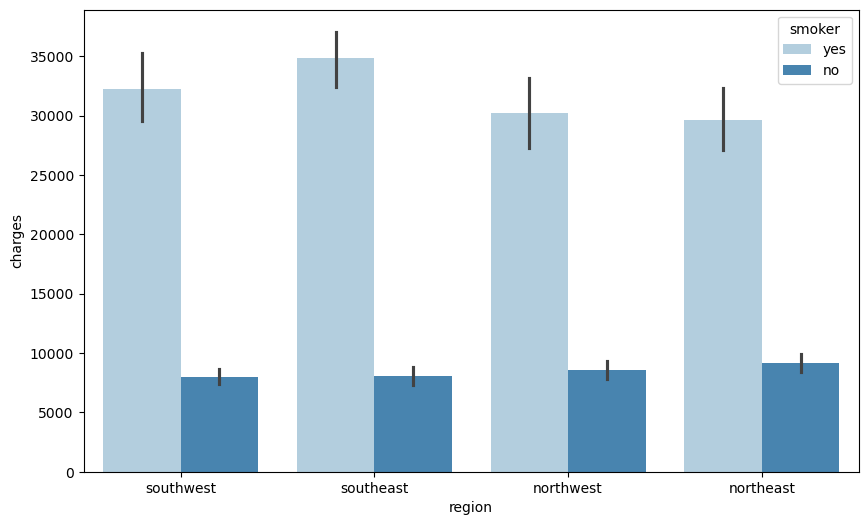

In [19]:
# charges by region wise
a,b = plt.subplots(1,1,figsize = (10,6))
b = sns.barplot(data = df, x = "region",y = "charges",hue="smoker",palette = "Blues")

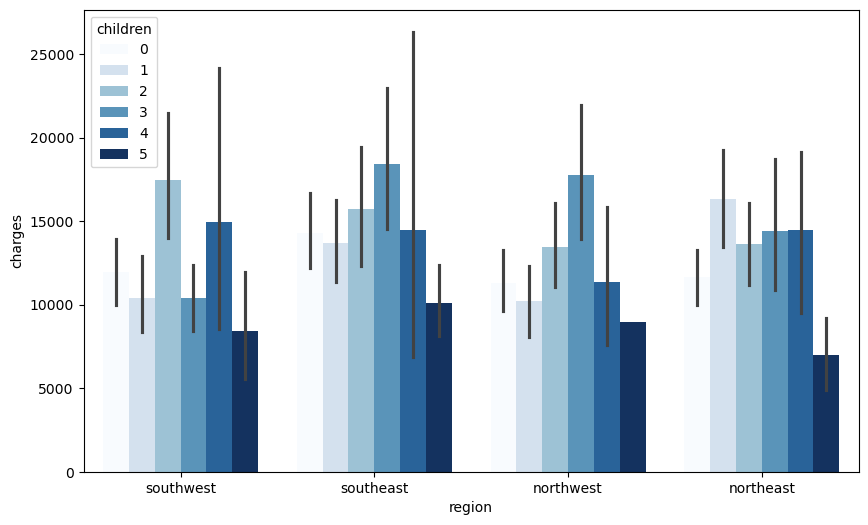

In [20]:
# charges by region wise
a,b = plt.subplots(1,1,figsize = (10,6))
b = sns.barplot(data = df, x = "region",y = "charges",hue="children",palette = "Blues")

<Axes: ylabel='charges'>

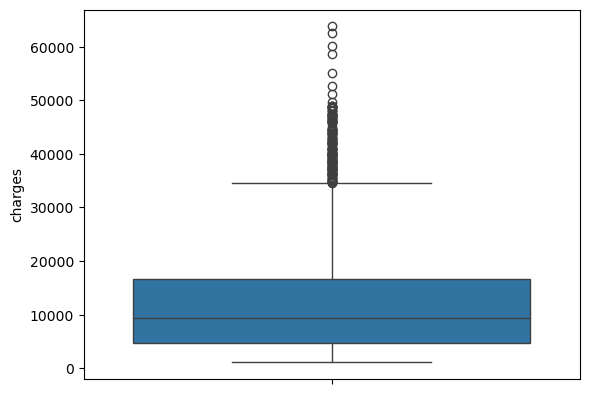

In [21]:
sns.boxplot(df["charges"])

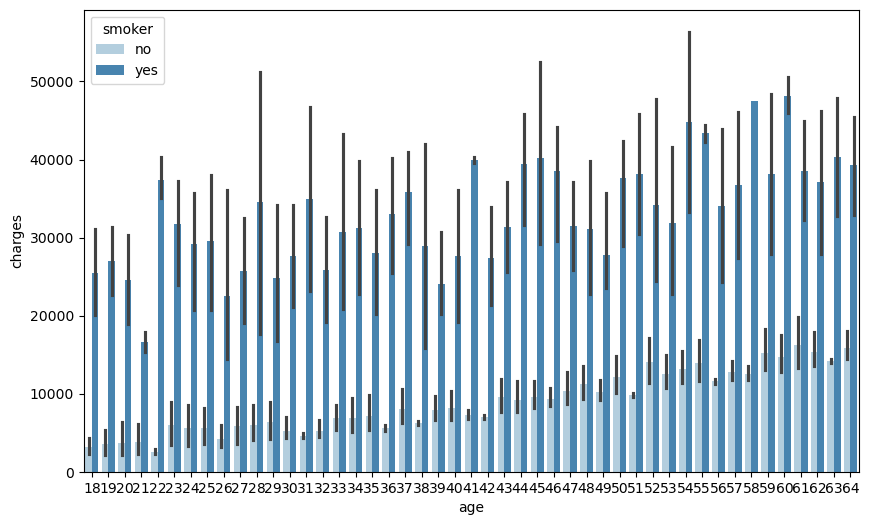

In [22]:
# charges by region wise
a,b = plt.subplots(1,1,figsize = (10,6))
b = sns.barplot(data = df, x = "age",y = "charges",hue="smoker",palette = "Blues")

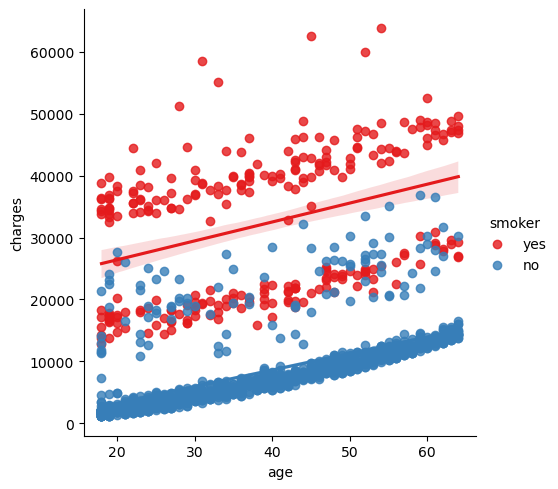

In [23]:
b = sns.lmplot(data = df, x = "age",y = "charges",hue="smoker",palette = "Set1")

In [24]:
import plotly.express as px
fig = px.pie(df["sex"].value_counts().reset_index(),values="count",names = "sex")
fig.update_traces(textposition = "inside",textinfo = "percent+label")
fig.update_layout(title_text = "Gender distribution of Policy")
fig.show()

KeyError: 'sex'

In [ ]:
import plotly.express as px
df1 = df["region"].value_counts().reset_index()
df1
fig = px.pie(df1,values="count",names = "region")
fig.update_traces(textposition = "inside",textinfo = "percent+label")
fig.update_layout(title_text = "Gender distribution of Policy")
fig.show()

In [ ]:
df["sex"].value_counts().reset_index()

In [ ]:
import plotly.express as px

fig = px.box(df,x="smoker",y = "charges",color = "sex")

fig.update_layout(title_text = "Distribution of charges")
fig.show()

In [ ]:
sns.kdeplot(df["age"])

In [ ]:
sns.kdeplot(np.log(df["age"]))

In [ ]:
sns.kdeplot(1/(df["age"]))

In [ ]:
sns.histplot(df["age"])

In [ ]:
sns.distplot(df["age"])

In [ ]:
df.columns

### 3. Feature Engineering

In [25]:
# column name changes
df.rename(columns = {"sex":"gender"},inplace=True)
df.columns

Index(['age', 'gender', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [26]:
df["gender"].unique()

array(['female', 'male'], dtype=object)

In [27]:
df["gender"].value_counts()

gender
male      676
female    662
Name: count, dtype: int64

In [28]:
df["gender"].replace({"female":1,"male":0},inplace=True)

In [29]:
df["gender"].value_counts()

gender
0    676
1    662
Name: count, dtype: int64

In [30]:
df["smoker"].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [31]:
df["smoker"].replace({"yes":1,"no":0},inplace=True)

In [32]:
df["smoker"].value_counts()

smoker
0    1064
1     274
Name: count, dtype: int64

#### Encoding

In [33]:
df["region"].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [34]:
df1 = pd.get_dummies(df,columns = ["region"]).astype("int")
df1.head()

,age,gender,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,0,1
1,18,0,33,1,0,1725,0,0,1,0
2,28,0,33,3,0,4449,0,0,1,0
3,33,0,22,0,0,21984,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0


In [35]:
from sklearn.preprocessing import OneHotEncoder

In [36]:
oe = OneHotEncoder()
array = oe.fit_transform(df[["region"]]).toarray()
df2 = pd.DataFrame(array,columns=df["region"].unique())
df2.head()

,southwest,southeast,northwest,northeast
0,0.0,0.0,0.0,1.0
1,0.0,0.0,1.0,0.0
2,0.0,0.0,1.0,0.0
3,0.0,1.0,0.0,0.0
4,0.0,1.0,0.0,0.0


In [37]:
df3 = pd.concat([df,df2],axis=1)
########## droping region column
df3.drop("region",axis=1,inplace=True) 
df3.head()

,age,gender,bmi,children,smoker,charges,southwest,southeast,northwest,northeast
0,19,1,27.900,0,1,16884.92400,0.0,0.0,0.0,1.0
1,18,0,33.770,1,0,1725.55230,0.0,0.0,1.0,0.0
2,28,0,33.000,3,0,4449.46200,0.0,0.0,1.0,0.0
3,33,0,22.705,0,0,21984.47061,0.0,1.0,0.0,0.0
4,32,0,28.880,0,0,3866.85520,0.0,1.0,0.0,0.0


In [38]:
df3["age"].min()

18

In [39]:
# binning 
age_bins = [0,18,30,45,60,100]
age_labels = ["0-18","19-30","31-45","46-60","61+"]
df3["age_binned"] = pd.cut(df["age"],bins=age_bins,labels=age_labels)
df3.head()

,age,gender,bmi,children,smoker,charges,southwest,southeast,northwest,northeast,age_binned
0,19,1,27.900,0,1,16884.92400,0.0,0.0,0.0,1.0,19-30
1,18,0,33.770,1,0,1725.55230,0.0,0.0,1.0,0.0,0-18
2,28,0,33.000,3,0,4449.46200,0.0,0.0,1.0,0.0,19-30
3,33,0,22.705,0,0,21984.47061,0.0,1.0,0.0,0.0,31-45
4,32,0,28.880,0,0,3866.85520,0.0,1.0,0.0,0.0,31-45


In [40]:
df3.isna().sum()

age           0
gender        0
bmi           0
children      0
smoker        0
charges       0
southwest     0
southeast     0
northwest     0
northeast     0
age_binned    0
dtype: int64

In [41]:
df3["age_binned"].dtype

CategoricalDtype(categories=['0-18', '19-30', '31-45', '46-60', '61+'], ordered=True, categories_dtype=object)

In [42]:
df3["age_binned"].value_counts().to_dict()

{'46-60': 409, '31-45': 394, '19-30': 375, '61+': 91, '0-18': 69}

In [43]:
df3["age_binned"].replace({'46-60': 3, '31-45': 2, '19-30':1, '61+': 4, '0-18': 0},inplace=True)

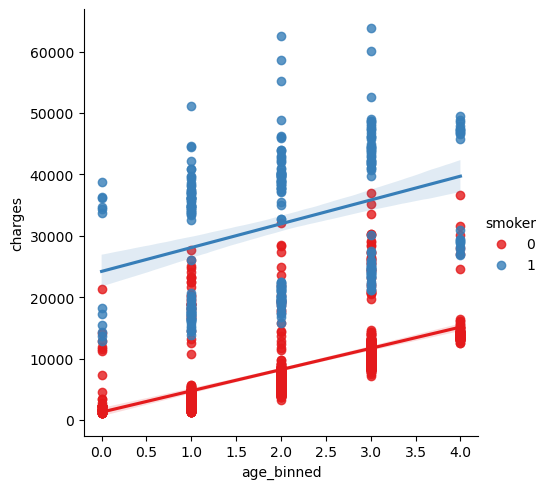

In [44]:
b = sns.lmplot(data = df3, x = "age_binned",y = "charges",hue="smoker",palette = "Set1")

In [45]:
df4 = df3.copy()
df4.isna().sum()

age           0
gender        0
bmi           0
children      0
smoker        0
charges       0
southwest     0
southeast     0
northwest     0
northeast     0
age_binned    0
dtype: int64

In [46]:
# binning 
bmi_bins = [0,18.5,24.5,30.5,100]
bmi_labels = ["Underweight","Normal","Overweight","Obese"]
df4["bmi_binned"] = pd.cut(df4["bmi"],bins=bmi_bins,labels=bmi_labels,include_lowest=True)
df4.isna().sum()

age           0
gender        0
bmi           0
children      0
smoker        0
charges       0
southwest     0
southeast     0
northwest     0
northeast     0
age_binned    0
bmi_binned    0
dtype: int64

In [47]:
df4[df4["bmi_binned"].isna() == True] # to check misisng records

,age,gender,bmi,children,smoker,charges,southwest,southeast,northwest,northeast,age_binned,bmi_binned


In [48]:
# bmi_bins = [0,18,24,30,50]
# bmi_labels = ["Underweight","Normal","Overweight","Obese"]
# age_bins = [0,18,30,45,60,100]
# age_labels = ["0-18","19-30","31-45","46-60","61+"]
# df3[["bmi","bmi_binned"]].head()

In [49]:
df4.head()

,age,gender,bmi,children,smoker,charges,southwest,southeast,northwest,northeast,age_binned,bmi_binned
0,19,1,27.900,0,1,16884.92400,0.0,0.0,0.0,1.0,1,Overweight
1,18,0,33.770,1,0,1725.55230,0.0,0.0,1.0,0.0,0,Obese
2,28,0,33.000,3,0,4449.46200,0.0,0.0,1.0,0.0,1,Obese
3,33,0,22.705,0,0,21984.47061,0.0,1.0,0.0,0.0,2,Normal
4,32,0,28.880,0,0,3866.85520,0.0,1.0,0.0,0.0,2,Overweight


In [50]:
df4.drop(["age","bmi"],axis=1,inplace=True)

In [51]:
df4.head()

,gender,children,smoker,charges,southwest,southeast,northwest,northeast,age_binned,bmi_binned
0,1,0,1,16884.92400,0.0,0.0,0.0,1.0,1,Overweight
1,0,1,0,1725.55230,0.0,0.0,1.0,0.0,0,Obese
2,0,3,0,4449.46200,0.0,0.0,1.0,0.0,1,Obese
3,0,0,0,21984.47061,0.0,1.0,0.0,0.0,2,Normal
4,0,0,0,3866.85520,0.0,1.0,0.0,0.0,2,Overweight


In [52]:
df4["bmi_binned"].value_counts().to_dict()

{'Obese': 653, 'Overweight': 467, 'Normal': 197, 'Underweight': 21}

In [53]:
df4["bmi_binned"].replace({'Obese': 3, 'Overweight': 2, 'Normal': 1, 'Underweight': 0},inplace=True)

In [54]:
df4["bmi_binned"].value_counts().to_dict()

{3: 653, 2: 467, 1: 197, 0: 21}

In [55]:
# 1. Problem statement
# 2. Data Gathering
# 3. EDA
# 4. Feature Engineering
# 5. Feature selection

#### 5. Feature selection

In [56]:
df4.corr() # x&y # cont vs cont # not applicable boc of all x are categorical

,gender,children,smoker,charges,southwest,southeast,northwest,northeast,age_binned,bmi_binned
gender,1.000000,-0.017163,-0.076185,-0.057292,0.002425,0.011156,-0.017117,0.004184,0.020911,-0.047834
children,-0.017163,1.000000,0.007673,0.067998,-0.022808,0.024806,-0.023066,0.021914,0.054553,0.004558
smoker,-0.076185,0.007673,1.000000,0.787251,0.002811,-0.036945,0.068498,-0.036945,-0.016135,-0.004248
charges,-0.057292,0.067998,0.787251,1.000000,0.006349,-0.039905,0.073982,-0.043210,0.288944,0.192256
southwest,0.002425,-0.022808,0.002811,0.006349,1.000000,-0.320177,-0.345561,-0.320177,-0.023524,-0.117460
southeast,0.011156,0.024806,-0.036945,-0.039905,-0.320177,1.000000,-0.346265,-0.320829,0.028856,-0.086593
northwest,-0.017117,-0.023066,0.068498,0.073982,-0.345561,-0.346265,1.000000,-0.346265,-0.037861,0.189073
northeast,0.004184,0.021914,-0.036945,-0.043210,-0.320177,-0.320829,-0.346265,1.000000,0.033933,0.007724
age_binned,0.020911,0.054553,-0.016135,0.288944,-0.023524,0.028856,-0.037861,0.033933,1.000000,0.117681
bmi_binned,-0.047834,0.004558,-0.004248,0.192256,-0.117460,-0.086593,0.189073,0.007724,0.117681,1.000000


#### vif

In [57]:
df5 = df4.copy()

In [58]:
df6 = df5.drop(["charges"],axis=1)
df6.isna().sum()

gender        0
children      0
smoker        0
southwest     0
southeast     0
northwest     0
northeast     0
age_binned    0
bmi_binned    0
dtype: int64

In [59]:
x_with_constant = sm.add_constant(df6)
vif_list = [variance_inflation_factor(x_with_constant.values,i) for i in range(x_with_constant.shape[1])]
vif_list

[0.0,
 1.0091952792105032,
 1.0048303534190075,
 1.0117776890127168,
 inf,
 inf,
 inf,
 inf,
 1.0225811513937297,
 1.0635778778350509]

In [60]:
s1 = pd.Series(vif_list,index= x_with_constant.columns)
s1

const         0.000000
gender        1.009195
children      1.004830
smoker        1.011778
southwest          inf
southeast          inf
northwest          inf
northeast          inf
age_binned    1.022581
bmi_binned    1.063578
dtype: float64

In [61]:
# feature selection :# missing value perentage error
df6.isna().mean()*100

gender        0.0
children      0.0
smoker        0.0
southwest     0.0
southeast     0.0
northwest     0.0
northeast     0.0
age_binned    0.0
bmi_binned    0.0
dtype: float64

In [62]:
# 1. Problem statement
# 2. Data Gathering
# 3. EDA
# 4. Feature Engineering
# 5. Feature selection
# 6. Model selection and Training
   # Linear regression, L1 AND L2

In [63]:
# LinearRegression,Ridge,Lasso

#### 6.1 LinearRegression

#### 6.1.1 LinearRegression

In [64]:
# spliting of data
x  =df5.drop("charges",axis=1)
y = df5["charges"]
x_train,x_test,y_train,y_test  = train_test_split(x,y,test_size=0.2,train_size=0.8,random_state=42)

In [65]:
# training
lr_model = LinearRegression()
lr_model.fit(x_train,y_train)

LinearRegression()

#### 7. Evalutaion

In [66]:
# evalution on testing
y_pred = lr_model.predict(x_test)
mse = mean_squared_error(y_test,y_pred)
print("Mean squared error\n",mse)

mae = mean_absolute_error(y_test,y_pred)
print("Mean absolute error\n",mae)

r2_score_test = r2_score(y_test,y_pred)
print("R2 score is ",r2_score_test)
print("**************************************************")
# evalution on training
y_pred = lr_model.predict(x_train)
mse = mean_squared_error(y_train,y_pred)
print("Mean squared error\n",mse)

mae = mean_absolute_error(y_train,y_pred)
print("Mean absolute error\n",mae)

r2_score_train = r2_score(y_train,y_pred)
print("R2 score is ",r2_score_train)

Mean squared error
 36519780.8009844
Mean absolute error
 4492.302315886161
R2 score is  0.7647659955088293
**************************************************
Mean squared error
 38530662.354441
Mean absolute error
 4463.281106552163
R2 score is  0.7330444435719381


#### 6.1.2 Ridge

In [67]:
# training
r_model = Ridge(alpha=1.0) #  alpha=1.0 lmbda : regularization parameter
r_model.fit(x_train,y_train)

Ridge()

In [68]:
# evalution on testing
y_pred = r_model.predict(x_test)
mse = mean_squared_error(y_test,y_pred)
print("Mean squared error\n",mse)

mae = mean_absolute_error(y_test,y_pred)
print("Mean absolute error\n",mae)

r2_score_test = r2_score(y_test,y_pred)
print("R2 score is ",r2_score_test)
print("**************************************************")
# evalution on training
y_pred = r_model.predict(x_train)
mse = mean_squared_error(y_train,y_pred)
print("Mean squared error\n",mse)

mae = mean_absolute_error(y_train,y_pred)
print("Mean absolute error\n",mae)

r2_score_train = r2_score(y_train,y_pred)
print("R2 score is ",r2_score_train)

Mean squared error
 36561627.39908842
Mean absolute error
 4502.874031708856
R2 score is  0.7644964500014237
**************************************************
Mean squared error
 38533657.227519915
Mean absolute error
 4470.910289197201
R2 score is  0.7330236939154213


#### 6.1.3 Lasso()

In [69]:
# training
l_model = Lasso(alpha=1.0) #  alpha=1.0 lmbda : regularization parameter
l_model.fit(x_train,y_train)

Lasso()

In [70]:
# evalution on testing
y_pred = l_model.predict(x_test)
mse = mean_squared_error(y_test,y_pred)
print("Mean squared error\n",mse)

mae = mean_absolute_error(y_test,y_pred)
print("Mean absolute error\n",mae)

r2_score_test = r2_score(y_test,y_pred)
print("R2 score is ",r2_score_test)
print("**************************************************")
# evalution on training
y_pred = l_model.predict(x_train)
mse = mean_squared_error(y_train,y_pred)
print("Mean squared error\n",mse)

mae = mean_absolute_error(y_train,y_pred)
print("Mean absolute error\n",mae)

r2_score_train = r2_score(y_train,y_pred)
print("R2 score is ",r2_score_train)

Mean squared error
 36517048.25501651
Mean absolute error
 4492.174678279813
R2 score is  0.7647835965928551
**************************************************
Mean squared error
 38530690.87839384
Mean absolute error
 4463.331331376974
R2 score is  0.7330442459467938


#### Hyperparameter Tuning

In [71]:
# To improve model performance we will try to implement GridSearchCV and RandomizedSearcfCV
# 1. GridSearchCV : Search in grid : means it will try all values
#  a1 = range(1,10) # 1,2,3,4,5,6,7,8,9
# 2. RandomizedSearchCV
#  a1 = range(1,10) # 2,7,

In [72]:
np.arange(0.01,3,0.01)

array([0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 , 0.11,
       0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21, 0.22,
       0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32, 0.33,
       0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43, 0.44,
       0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54, 0.55,
       0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65, 0.66,
       0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76, 0.77,
       0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87, 0.88,
       0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99,
       1.  , 1.01, 1.02, 1.03, 1.04, 1.05, 1.06, 1.07, 1.08, 1.09, 1.1 ,
       1.11, 1.12, 1.13, 1.14, 1.15, 1.16, 1.17, 1.18, 1.19, 1.2 , 1.21,
       1.22, 1.23, 1.24, 1.25, 1.26, 1.27, 1.28, 1.29, 1.3 , 1.31, 1.32,
       1.33, 1.34, 1.35, 1.36, 1.37, 1.38, 1.39, 1.4 , 1.41, 1.42, 1.43,
       1.44, 1.45, 1.46, 1.47, 1.48, 1.49, 1.5 , 1.

#### 6.1.2.1 Ridge with parameter tuning

In [73]:
# gridsearchcv
estimate = Ridge()
paramter_alpha_grid = {"alpha":np.arange(0.01,3,0.01)}
gdsearch = GridSearchCV(estimator=estimate,param_grid=paramter_alpha_grid,cv=5) # 100/5
gdsearch.fit(x_train,y_train)
gdsearch.best_estimator_

Ridge(alpha=1.18)

In [74]:
# evalution on testing
r_model = Ridge(alpha=1.18)
r_model.fit(x_train,y_train)
############################################ prediction on testing ###############
y_pred = r_model.predict(x_test)
mse = mean_squared_error(y_test,y_pred)
print("Mean squared error\n",mse)

mae = mean_absolute_error(y_test,y_pred)
print("Mean absolute error\n",mae)

r2_score_test = r2_score(y_test,y_pred)
print("R2 score is ",r2_score_test)
print("**************************************************")
# evalution on training
y_pred = r_model.predict(x_train)
mse = mean_squared_error(y_train,y_pred)
print("Mean squared error\n",mse)

mae = mean_absolute_error(y_train,y_pred)
print("Mean absolute error\n",mae)

r2_score_train = r2_score(y_train,y_pred)
print("R2 score is ",r2_score_train)

Mean squared error
 36569733.96931792
Mean absolute error
 4504.762791813479
R2 score is  0.7644442333414123
**************************************************
Mean squared error
 38534823.792140156
Mean absolute error
 4472.283544471646
R2 score is  0.733015611497724


In [75]:
estimate = Ridge()  # param_grid change to param_distributions
paramter_alpha_grid = {"alpha":np.arange(0.01,3,0.01)}
randomized = RandomizedSearchCV(estimator=estimate,param_distributions=paramter_alpha_grid,cv=5) # 100/5
randomized.fit(x_train,y_train)
randomized.best_estimator_

Ridge(alpha=1.1500000000000001)

In [76]:
# evalution on testing
r_model = Ridge(alpha=1.24)
r_model.fit(x_train,y_train)
############################################ prediction on testing ###############
y_pred = r_model.predict(x_test)
mse = mean_squared_error(y_test,y_pred)
print("Mean squared error\n",mse)

mae = mean_absolute_error(y_test,y_pred)
print("Mean absolute error\n",mae)

r2_score_test = r2_score(y_test,y_pred)
print("R2 score is ",r2_score_test)
print("**************************************************")
# evalution on training
y_pred = r_model.predict(x_train)
mse = mean_squared_error(y_train,y_pred)
print("Mean squared error\n",mse)

mae = mean_absolute_error(y_train,y_pred)
print("Mean absolute error\n",mae)

r2_score_train = r2_score(y_train,y_pred)
print("R2 score is ",r2_score_train)

Mean squared error
 36572474.51283098
Mean absolute error
 4505.391426364261
R2 score is  0.7644265807429871
**************************************************
Mean squared error
 38535254.58077041
Mean absolute error
 4472.744001991565
R2 score is  0.7330126268249604


#### 6.1.2.3 Lasso

In [77]:
estimate = Lasso()
paramter_alpha_grid = {"alpha":np.arange(0.01,3,0.01)}
gdsearch = GridSearchCV(estimator=estimate,param_grid=paramter_alpha_grid,cv=5) # 100/5
gdsearch.fit(x_train,y_train)
gdsearch.best_estimator_

Lasso(alpha=2.9899999999999998)

In [78]:
# evalution on testing
l_model = Lasso(alpha=2.9899999999999998)
l_model.fit(x_train,y_train)
############################################ prediction on testing ###############
y_pred = l_model.predict(x_test)
mse = mean_squared_error(y_test,y_pred)
print("Mean squared error\n",mse)

mae = mean_absolute_error(y_test,y_pred)
print("Mean absolute error\n",mae)

r2_score_test = r2_score(y_test,y_pred)
print("R2 score is ",r2_score_test)
print("**************************************************")
# evalution on training
y_pred = l_model.predict(x_train)
mse = mean_squared_error(y_train,y_pred)
print("Mean squared error\n",mse)

mae = mean_absolute_error(y_train,y_pred)
print("Mean absolute error\n",mae)

r2_score_train = r2_score(y_train,y_pred)
print("R2 score is ",r2_score_train)

Mean squared error
 36511806.03071483
Mean absolute error
 4491.911186254763
R2 score is  0.764817363208861
**************************************************
Mean squared error
 38530915.17023851
Mean absolute error
 4463.4262874860215
R2 score is  0.7330426919648341


In [79]:
estimate = Lasso()
paramter_alpha_grid = {"alpha":np.arange(0.01,3,0.01)}
randomizedsearch = RandomizedSearchCV(estimator=estimate,param_distributions=paramter_alpha_grid,cv=5) # 100/5
randomizedsearch.fit(x_train,y_train)
randomizedsearch.best_estimator_

Lasso(alpha=2.6599999999999997)

In [80]:
# evalution on testing
l_model = Lasso(alpha=2.8899999999999997)
l_model.fit(x_train,y_train)
############################################ prediction on testing ###############
y_pred = l_model.predict(x_test)
mse = mean_squared_error(y_test,y_pred)
print("Mean squared error\n",mse)

mae = mean_absolute_error(y_test,y_pred)
print("Mean absolute error\n",mae)

r2_score_test = r2_score(y_test,y_pred)
print("R2 score is ",r2_score_test)
print("**************************************************")
# evalution on training
y_pred = l_model.predict(x_train)
mse = mean_squared_error(y_train,y_pred)
print("Mean squared error\n",mse)

mae = mean_absolute_error(y_train,y_pred)
print("Mean absolute error\n",mae)

r2_score_train = r2_score(y_train,y_pred)
print("R2 score is ",r2_score_train)

Mean squared error
 36512063.254578754
Mean absolute error
 4491.924427060042
R2 score is  0.7648157063588407
**************************************************
Mean squared error
 38530898.57766755
Mean absolute error
 4463.421515822249
R2 score is  0.7330428069246802


In [81]:
# Conclusion : better to go with Linear Regression

#### KNN Regression

#### scaling

In [82]:
std_scalr = StandardScaler()
std_scalr.fit(x_train)
array = std_scalr.transform(x_train)
std_xtrain = pd.DataFrame(array,columns=x_train.columns)
std_xtrain.head(2)

,gender,children,smoker,southwest,southeast,northwest,northeast,age_binned,bmi_binned
0,1.024602,0.734336,-0.508747,-0.576631,1.783168,-0.599661,-0.572314,0.901714,-1.672731
1,1.024602,-0.911192,-0.508747,1.734212,-0.560800,-0.599661,-0.572314,0.901714,-1.672731


In [83]:
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(std_xtrain,y_train)

KNeighborsRegressor()

In [84]:
x_test.head(1)

,gender,children,smoker,southwest,southeast,northwest,northeast,age_binned,bmi_binned
764,1,2,0,1.0,0.0,0.0,0.0,2,2


In [85]:
############################################ prediction on testing ###############
array = std_scalr.transform(x_test)
std_test_df = pd.DataFrame(array,columns = x_test.columns)
###############################

y_pred = knn_model.predict(std_test_df) # need to pass scaled test data

mse = mean_squared_error(y_test,y_pred)
print("Mean squared error\n",mse)

mae = mean_absolute_error(y_test,y_pred)
print("Mean absolute error\n",mae)

r2_score_test = r2_score(y_test,y_pred)
print("R2 score is ",r2_score_test)
print("**************************************************")
# evalution on training
y_pred = knn_model.predict(std_xtrain)
mse = mean_squared_error(y_train,y_pred)
print("Mean squared error\n",mse)

mae = mean_absolute_error(y_train,y_pred)
print("Mean absolute error\n",mae)

r2_score_train = r2_score(y_train,y_pred)
print("R2 score is ",r2_score_train)

Mean squared error
 34724681.56465488
Mean absolute error
 3956.3841803843284
R2 score is  0.7763287259677552
**************************************************
Mean squared error
 22237075.595857676
Mean absolute error
 3054.071127893458
R2 score is  0.8459328097083477


#### To select best paramter using Hyperparameter Tuning

In [86]:
knn_model = KNeighborsRegressor(n_neighbors=5,p=2) # ed, p=1
knn_model.fit(std_xtrain,y_train)
 # Power parameter for the Minkowski metric. When p = 1, this is
 #    equivalent to using manhattan_distance (l1), and euclidean_distance
 #    (l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.

KNeighborsRegressor()

##### for p=2 k?

In [87]:
r2_score_train_list = []
r2_score_test_list = []
k_values = range(2,21)
array = std_scalr.transform(x_test)
std_test_df = pd.DataFrame(array,columns = x_test.columns)
###############################
for k in k_values:
    knn_reg = KNeighborsRegressor(n_neighbors=k,p=2)
    knn_reg.fit(std_xtrain,y_train)
    r2_train = knn_reg.score(std_xtrain,y_train)
    r2_score_train_list.append(r2_train)

    ################ testing side #########3
    r2_test = knn_reg.score(std_test_df,y_test)
    r2_score_test_list.append(r2_test)


In [88]:
r2_score_test_list

[0.7735702222871295,
 0.7482058134948837,
 0.7702299806579742,
 0.7763287259677552,
 0.7838791657173119,
 0.7855795437672093,
 0.785909297470691,
 0.7927646618811743,
 0.7870464640523922,
 0.7750872496466704,
 0.7743479669127924,
 0.7658689231338056,
 0.7687130261428938,
 0.7666800521409836,
 0.7708850362389137,
 0.7688360451899052,
 0.767768001152235,
 0.764860968172457,
 0.7621319903472052]

In [89]:
r2_score_train_list

[0.8588390632774876,
 0.8639183007075889,
 0.8542287457047457,
 0.8459328097083477,
 0.838276999438089,
 0.8325572408664735,
 0.8260512132495531,
 0.8210399340700758,
 0.812576078179045,
 0.8056079260109964,
 0.8042433417535281,
 0.7985534398049868,
 0.794126118769483,
 0.7900759179767654,
 0.7893966681715319,
 0.7882685277162087,
 0.7832563281721661,
 0.7802454267467313,
 0.7781171594000985]

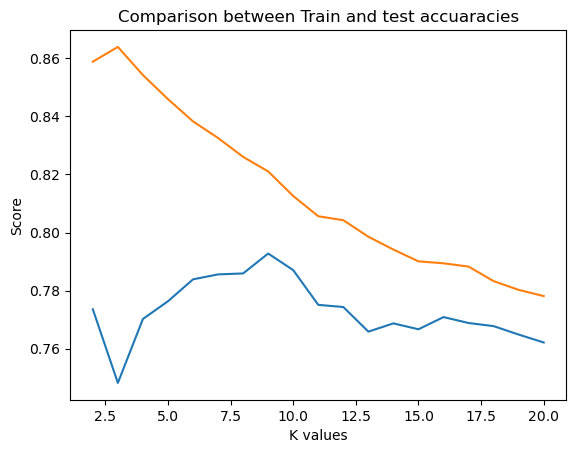

In [90]:
plt.plot(k_values,r2_score_test_list)
plt.plot(k_values,r2_score_train_list)
plt.xlabel("K values")
plt.ylabel("Score")
plt.title("Comparison between Train and test accuaracies")
plt.savefig("k values.jpeg")

In [91]:
knn_model = KNeighborsRegressor(n_neighbors=9,p=2) # ed, p=1
knn_model.fit(std_xtrain,y_train)
knn_model.score(std_xtrain,y_train)

0.8210399340700758

In [92]:
knn_model.score(std_test_df,y_test)

0.7927646618811743

In [93]:
std_xtrain.head(2)

,gender,children,smoker,southwest,southeast,northwest,northeast,age_binned,bmi_binned
0,1.024602,0.734336,-0.508747,-0.576631,1.783168,-0.599661,-0.572314,0.901714,-1.672731
1,1.024602,-0.911192,-0.508747,1.734212,-0.560800,-0.599661,-0.572314,0.901714,-1.672731


### DecisionTree

In [94]:
dt_model = DecisionTreeRegressor()
dt_model.fit(x_train,y_train)

DecisionTreeRegressor()

In [95]:
############ testing
y_pred = dt_model.predict(x_test) # need to pass scaled test data

mse = mean_squared_error(y_test,y_pred)
print("Mean squared error\n",mse)

mae = mean_absolute_error(y_test,y_pred)
print("Mean absolute error\n",mae)

r2_score_test = r2_score(y_test,y_pred)
print("R2 score is ",r2_score_test)
print("**************************************************")
# evalution on training
y_pred = dt_model.predict(x_train)
mse = mean_squared_error(y_train,y_pred)
print("Mean squared error\n",mse)

mae = mean_absolute_error(y_train,y_pred)
print("Mean absolute error\n",mae)

r2_score_train = r2_score(y_train,y_pred)
print("R2 score is ",r2_score_train)

Mean squared error
 36201593.560062714
Mean absolute error
 3533.8378299457027
R2 score is  0.7668155274944646
**************************************************
Mean squared error
 12740853.261745904
Mean absolute error
 1799.0944979235128
R2 score is  0.911726366378811


### Best paramater for DecisionTree

In [96]:
dt_model = DecisionTreeRegressor()
hyper_paramter = { "criterion":["squared_error", "friedman_mse", "absolute_error","poisson"],
    "max_depth":np.arange(2,4),
    "min_samples_split":np.arange(2,4),
    "min_samples_leaf":np.arange(1,2)}
gdscv_dt_model = GridSearchCV(dt_model,hyper_paramter,cv=5)
gdscv_dt_model.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(),
             param_grid={'criterion': ['squared_error', 'friedman_mse',
                                       'absolute_error', 'poisson'],
                         'max_depth': array([2, 3]),
                         'min_samples_leaf': array([1]),
                         'min_samples_split': array([2, 3])})

In [97]:
gdscv_dt_model.best_estimator_

DecisionTreeRegressor(criterion='poisson', max_depth=3)

In [98]:
############ testing
dt_model = gdscv_dt_model.best_estimator_
y_pred = dt_model.predict(x_test) # need to pass scaled test data

mse = mean_squared_error(y_test,y_pred)
print("Mean squared error\n",mse)

mae = mean_absolute_error(y_test,y_pred)
print("Mean absolute error\n",mae)

r2_score_test = r2_score(y_test,y_pred)
print("R2 score is ",r2_score_test)
print("**************************************************")
# evalution on training
y_pred = dt_model.predict(x_train)
mse = mean_squared_error(y_train,y_pred)
print("Mean squared error\n",mse)

mae = mean_absolute_error(y_train,y_pred)
print("Mean absolute error\n",mae)

r2_score_train = r2_score(y_train,y_pred)
print("R2 score is ",r2_score_train)

Mean squared error
 21299103.181412082
Mean absolute error
 3008.889470371392
R2 score is  0.8628065880039689
**************************************************
Mean squared error
 25212446.956508644
Mean absolute error
 3109.753008547899
R2 score is  0.8253182687524705


In [99]:
# np.sqrt(10)

#### RandomForest

In [100]:
rf_model = RandomForestRegressor()
hyper_parameter_rf_model = {"n_estimators" :np.arange(10,12),
                  "criterion": ["squared_error", "absolute_error", "friedman_mse", "poisson"],
                  "max_depth":np.arange(2,4),
        "min_samples_split": np.arange(3,4),
        "min_samples_leaf":np.arange(2,4),
"max_features":["sqrt","log2"],
"random_state" :[42,15]}
gscv_rf_model = GridSearchCV(rf_model,hyper_parameter_rf_model,cv=5)
gscv_rf_model.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid={'criterion': ['squared_error', 'absolute_error',
                                       'friedman_mse', 'poisson'],
                         'max_depth': array([2, 3]),
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': array([2, 3]),
                         'min_samples_split': array([3]),
                         'n_estimators': array([10, 11]),
                         'random_state': [42, 15]})

In [101]:
gscv_rf_model.best_estimator_

RandomForestRegressor(criterion='poisson', max_depth=3, max_features='sqrt',
                      min_samples_leaf=2, min_samples_split=3, n_estimators=11,
                      random_state=42)

In [102]:
############ testing
rf_dt_model = gscv_rf_model.best_estimator_
y_pred = rf_dt_model.predict(x_test) # need to pass scaled test data

mse = mean_squared_error(y_test,y_pred)
print("Mean squared error\n",mse)

mae = mean_absolute_error(y_test,y_pred)
print("Mean absolute error\n",mae)

r2_score_test = r2_score(y_test,y_pred)
print("R2 score is ",r2_score_test)
print("**************************************************")
# evalution on training
y_pred = rf_dt_model.predict(x_train)
mse = mean_squared_error(y_train,y_pred)
print("Mean squared error\n",mse)

mae = mean_absolute_error(y_train,y_pred)
print("Mean absolute error\n",mae)

r2_score_train = r2_score(y_train,y_pred)
print("R2 score is ",r2_score_train)

Mean squared error
 34589108.63695222
Mean absolute error
 4284.569437552446
R2 score is  0.7772019886759263
**************************************************
Mean squared error
 36529122.14465417
Mean absolute error
 4225.947893857617
R2 score is  0.7469118999759206


In [103]:
# dt_model = 0.82 # single tree
# rf_model = 0.84 # 
# ad_model = 0.85

#### Adaboost

In [104]:
ad_model = AdaBoostRegressor() #
hyper_parameter_ad_model = {"n_estimators" : np.arange(10,12),
                  "learning_rate": np.arange(0,1,0.001)}
gscv_ad_model = GridSearchCV(ad_model,hyper_parameter_ad_model,cv=5)
gscv_ad_model.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=AdaBoostRegressor(),
             param_grid={'learning_rate': array([0.   , 0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008,
       0.009, 0.01 , 0.011, 0.012, 0.013, 0.014, 0.015, 0.016, 0.017,
       0.018, 0.019, 0.02 , 0.021, 0.022, 0.023, 0.024, 0.025, 0.026,
       0.027, 0.028, 0.029, 0.03 , 0.031, 0.032, 0.033, 0.034, 0.035,
       0.036, 0.037, 0.038, 0.039, 0.04 , 0.041, 0.042, 0.043, 0.044,
       0.04...
       0.945, 0.946, 0.947, 0.948, 0.949, 0.95 , 0.951, 0.952, 0.953,
       0.954, 0.955, 0.956, 0.957, 0.958, 0.959, 0.96 , 0.961, 0.962,
       0.963, 0.964, 0.965, 0.966, 0.967, 0.968, 0.969, 0.97 , 0.971,
       0.972, 0.973, 0.974, 0.975, 0.976, 0.977, 0.978, 0.979, 0.98 ,
       0.981, 0.982, 0.983, 0.984, 0.985, 0.986, 0.987, 0.988, 0.989,
       0.99 , 0.991, 0.992, 0.993, 0.994, 0.995, 0.996, 0.997, 0.998,
       0.999]),
                         'n_estimators': array([10, 11])})

In [105]:
gscv_ad_model.best_estimator_

AdaBoostRegressor(learning_rate=0.022, n_estimators=11)

In [106]:
############ testing
ad_dt_model = gscv_ad_model.best_estimator_
y_pred = ad_dt_model.predict(x_test) # need to pass scaled test data

mse = mean_squared_error(y_test,y_pred)
print("Mean squared error\n",mse)

mae = mean_absolute_error(y_test,y_pred)
print("Mean absolute error\n",mae)

r2_score_test = r2_score(y_test,y_pred)
print("R2 score is ",r2_score_test)
print("**************************************************")
# evalution on training
y_pred = ad_dt_model.predict(x_train)
mse = mean_squared_error(y_train,y_pred)
print("Mean squared error\n",mse)

mae = mean_absolute_error(y_train,y_pred)
print("Mean absolute error\n",mae)

r2_score_train = r2_score(y_train,y_pred)
print("R2 score is ",r2_score_train)

Mean squared error
 20701889.46614202
Mean absolute error
 2932.921342175952
R2 score is  0.866653406651255
**************************************************
Mean squared error
 24774811.858772565
Mean absolute error
 3091.9085721126717
R2 score is  0.828350376530787


#### Model save

In [108]:
with open("dt_model.pkl","wb") as file:
    pickle.dump(dt_model,file) # knn_model 

In [109]:
# with open("std_scalar.pkl","wb") as file:
#     pickle.dump(std_scalr,file) # std_scalr 

In [110]:
list(x.columns)

['gender',
 'children',
 'smoker',
 'southwest',
 'southeast',
 'northwest',
 'northeast',
 'age_binned',
 'bmi_binned']

In [111]:
# data need to be stored: gender :male and female :
# df["gender"].replace({"female":1,"male":0},inplace=True)
# df["smoker"].replace({"yes":1,"no":0},inplace=True)
project_data = {"gender": {"female":1,"male":0},
               "smoker" :{"yes":1,"no":0},
               "columns":list(x.columns)}
project_data

{'gender': {'female': 1, 'male': 0},
 'smoker': {'yes': 1, 'no': 0},
 'columns': ['gender',
  'children',
  'smoker',
  'southwest',
  'southeast',
  'northwest',
  'northeast',
  'age_binned',
  'bmi_binned']}

In [112]:
# storing data into json format
with open("project_data.json","w") as file:
    json.dump(project_data,file)

#### Prediction on single user input

In [113]:
gender =  "male"
age =  47
children = 3
smoker =  "yes"
bmi = 27.58
region = "northwest"
# charges = ?

In [114]:
project_data["gender"][gender]

0

In [115]:
project_data["smoker"][smoker]

1

In [116]:
# project_data
x.columns

Index(['gender', 'children', 'smoker', 'southwest', 'southeast', 'northwest',
       'northeast', 'age_binned', 'bmi_binned'],
      dtype='object')

In [117]:
column_names =project_data["columns"]
column_names

['gender',
 'children',
 'smoker',
 'southwest',
 'southeast',
 'northwest',
 'northeast',
 'age_binned',
 'bmi_binned']

In [118]:
x.columns

column_names = x.columns
test_array = np.zeros(len(column_names))
test_array[0] = project_data["gender"][gender]
test_array[1] = children
test_array[2] = project_data["smoker"][smoker]
print(test_array)
index_region = np.where(x.columns == region)[0][0]
test_array[index_region] =  1  #region  = "northwest"
test_array[7] = (0 if age < 19 else 
                1 if 19<= age < 31 else
                2 if 31<= age <46 else
                3 if 46<= age <61 else
                4 )
test_array[8] = (0 if bmi <= 18.5 else 
                1 if 18.5< bmi <= 24.5 else
                2 if 24.5< bmi <= 30.5 else
                3  )
print(test_array) 

[0. 3. 1. 0. 0. 0. 0. 0. 0.]
[0. 3. 1. 0. 0. 1. 0. 3. 2.]


In [119]:
gender =  "male"
age =  47
children = 3
smoker =  "yes"
bmi = 27.58
region = "northwest"
# charges = ?

In [120]:
pred_charges = dt_model.([test_array])
print("Predicted charges are",np.around(pred_charges[0],2))

AttributeError: 'float' object has no attribute 'predict'